Tech Layoffs 2020–2025: Exploratory Data Analysis & Trend Forecasting


Importing the libraries

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading the dataset

In [3]:
df = pd.read_csv("tech_layoffs_til_2025.csv")
df.head()

,Nr,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude
0,1,Tamara Mellon,Los Angeles,other,California,USA,North America,20.0,2020-03-12,40.0,50.0,30.0,Retail,Series C,90.0,2020,34.053691,-118.242766
1,2,HopSkipDrive,Los Angeles,other,California,USA,North America,8.0,2020-03-13,10.0,80.0,72.0,Transportation,Unknown,45.0,2020,34.053691,-118.242766
2,3,Panda Squad,San Francisco,San Francisco Bay Area,California,USA,North America,6.0,2020-03-13,75.0,8.0,2.0,Consumer,Seed,1.0,2020,37.779259,-122.419329
3,4,Help.com,Austin,other,Texas,USA,North America,16.0,2020-03-16,100.0,16.0,0.0,Support,Seed,6.0,2020,30.271129,-97.743700
4,5,Inspirato,Denver,other,Colorado,USA,North America,130.0,2020-03-16,22.0,591.0,461.0,Travel,Series C,79.0,2020,39.739236,-104.984862


Understanding the data set
   - Checking shape (rows, columns)
   - Inspecting data types
   - Reading column descriptions

In [4]:
df.shape

(2412, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Nr                           2412 non-null   int64  
 1   Company                      2412 non-null   object 
 2   Location_HQ                  2412 non-null   object 
 3   Region                       2412 non-null   object 
 4   USState                      2411 non-null   object 
 5   Country                      2412 non-null   object 
 6   Continent                    2412 non-null   object 
 7   Laid_Off                     2040 non-null   float64
 8   Date_layoffs                 2412 non-null   object 
 9   Percentage                   1963 non-null   float64
 10  Company_Size_before_Layoffs  1769 non-null   float64
 11  Company_Size_after_layoffs   1857 non-null   float64
 12  Industry                     2412 non-null   object 
 13  Stage             

Checking the Null values

In [6]:
df.isnull().sum() 

Nr                               0
Company                          0
Location_HQ                      0
Region                           0
USState                          1
Country                          0
Continent                        0
Laid_Off                       372
Date_layoffs                     0
Percentage                     449
Company_Size_before_Layoffs    643
Company_Size_after_layoffs     555
Industry                         0
Stage                          164
Money_Raised_in__mil           364
Year                             0
latitude                         0
longitude                        0
dtype: int64

Since USState only have one null value, we can safely drop that row

In [7]:
df.dropna(subset=['USState'], inplace = True)

Investigating the layoffs and percentage

In [8]:
df[['Laid_Off', 'Percentage']].isnull().sum()

Laid_Off      372
Percentage    449
dtype: int64

Total null values  in Laid_off = 372

Total null values in Percentage = 449


In [9]:
df[df['Laid_Off'].isnull() & df['Percentage'].isnull()].shape

(165, 18)

Insights
   - Rows where BOTH (Laid_off and percentage) are null = 165
   - Null values in Laid_off which have corresponding percentage values is 207 rows (372-165 = 207)


Therefore, we can safely remove those rows, which have null values in both percentage and layoff, as they aren't providing any meaningful information. (165) 

In [10]:
df = df.dropna(subset=['Laid_Off', 'Percentage'], how='all')


In [11]:
df.reset_index(drop=True, inplace=True)

In [12]:
df[df['Laid_Off'].isnull() & df['Percentage'].isnull()].shape

(0, 18)

We cannot compute mean/median/mode in place of null values in layoff because that will create fake data

Checking for duplicates

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.drop_duplicates(inplace=True)  #Duplicates were removed

Verifying the Datatypes

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2246 entries, 0 to 2245
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Nr                           2246 non-null   int64  
 1   Company                      2246 non-null   object 
 2   Location_HQ                  2246 non-null   object 
 3   Region                       2246 non-null   object 
 4   USState                      2246 non-null   object 
 5   Country                      2246 non-null   object 
 6   Continent                    2246 non-null   object 
 7   Laid_Off                     2039 non-null   float64
 8   Date_layoffs                 2246 non-null   object 
 9   Percentage                   1962 non-null   float64
 10  Company_Size_before_Layoffs  1768 non-null   float64
 11  Company_Size_after_layoffs   1856 non-null   float64
 12  Industry                     2246 non-null   object 
 13  Stage             

Handling wrong datatype

In [16]:
df['Date_layoffs'] = pd.to_datetime(df['Date_layoffs'], format='mixed', dayfirst=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2246 entries, 0 to 2245
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Nr                           2246 non-null   int64         
 1   Company                      2246 non-null   object        
 2   Location_HQ                  2246 non-null   object        
 3   Region                       2246 non-null   object        
 4   USState                      2246 non-null   object        
 5   Country                      2246 non-null   object        
 6   Continent                    2246 non-null   object        
 7   Laid_Off                     2039 non-null   float64       
 8   Date_layoffs                 2246 non-null   datetime64[ns]
 9   Percentage                   1962 non-null   float64       
 10  Company_Size_before_Layoffs  1768 non-null   float64       
 11  Company_Size_after_layoffs   1856 non-null 

Engineering new features for time

In [17]:
df['Year_layoff'] = df['Date_layoffs'].dt.year
df['Month_layoff'] = df['Date_layoffs'].dt.month
df.head()

,Nr,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude,Year_layoff,Month_layoff
0,1,Tamara Mellon,Los Angeles,other,California,USA,North America,20.0,2020-03-12,40.0,50.0,30.0,Retail,Series C,90.0,2020,34.053691,-118.242766,2020,3
1,2,HopSkipDrive,Los Angeles,other,California,USA,North America,8.0,2020-03-13,10.0,80.0,72.0,Transportation,Unknown,45.0,2020,34.053691,-118.242766,2020,3
2,3,Panda Squad,San Francisco,San Francisco Bay Area,California,USA,North America,6.0,2020-03-13,75.0,8.0,2.0,Consumer,Seed,1.0,2020,37.779259,-122.419329,2020,3
3,4,Help.com,Austin,other,Texas,USA,North America,16.0,2020-03-16,100.0,16.0,0.0,Support,Seed,6.0,2020,30.271129,-97.743700,2020,3
4,5,Inspirato,Denver,other,Colorado,USA,North America,130.0,2020-03-16,22.0,591.0,461.0,Travel,Series C,79.0,2020,39.739236,-104.984862,2020,3


Now that we don't have duplicates, we can check for outliers

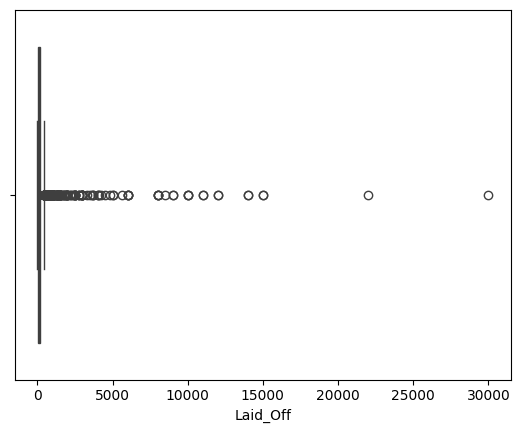

In [20]:
sns.boxplot(x = df["Laid_Off"])
plt.show()

These outliers cannot be removed as large layoffs are the genuine numbers and not errors.

PHASE-2 EDA

Yearly total number of layoffs happening: Year_layoff
2020     61610.0
2021      6790.0
2022    127812.0
2023    179128.0
2024    171024.0
2025    199745.0
Name: Laid_Off, dtype: float64


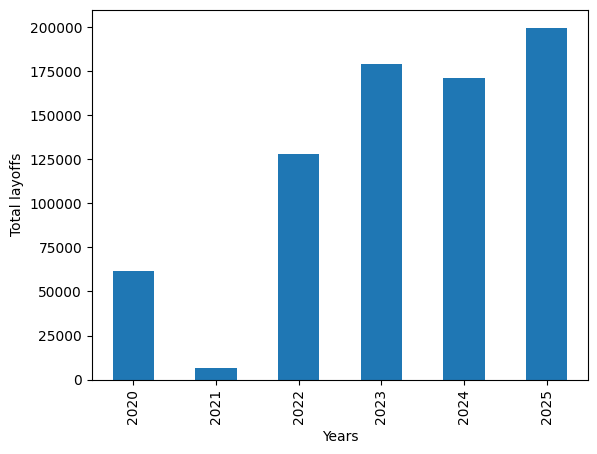

In [22]:
yearly = df.groupby("Year_layoff")['Laid_Off'].sum()
print(f'Yearly total number of layoffs happening: {yearly}')
yearly.plot(kind='bar')
plt.xlabel("Years")
plt.ylabel("Total layoffs") 
plt.savefig('Layoffs by Year.png')

Insights 
   - Total layoff: 745407.0
   - Average layoff: 366.4734513274336
   - In year 2025, maximum layoffs were seen, while in 2021 minimum layoffs were seen

Monthly total number of layoffs happening: Month_layoff
1     103839.0
2      61059.0
3      57740.0
4     100600.0
5      64114.0
6      45034.0
7      55108.0
8      54637.0
9      32234.0
10     52943.0
11    100339.0
12     18462.0
Name: Laid_Off, dtype: float64


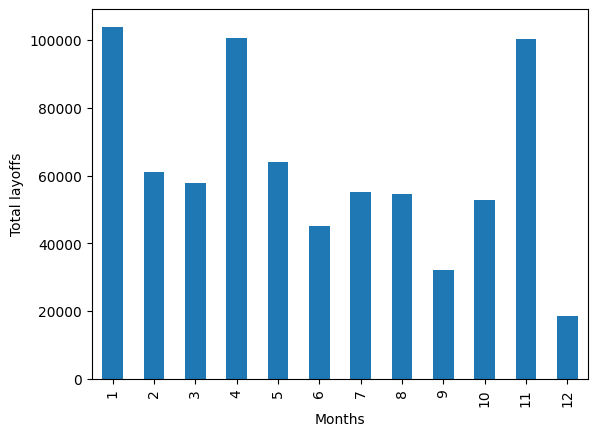

In [23]:
monthly = df.groupby('Month_layoff')['Laid_Off'].sum()
print(f'Monthly total number of layoffs happening: {monthly}')
monthly.plot(kind='bar')
plt.xlabel("Months")
plt.ylabel("Total layoffs") 
plt.savefig('Layoffs by Month.png')


Insights
   - In month of January, maximum layoffs were seen, while in December least layoffs were seen
   - In the months from May to October there was minimal up and down in the layoff
   - In the month of January, April and November a spike was seen 

Monthly total number of layoffs happening in 2025: Month_layoff
1      2807.0
2     15830.0
3      9125.0
4     24545.0
5     10397.0
6      1306.0
7     29066.0
8      8956.0
9     21340.0
10    34124.0
11    40638.0
12     1611.0
Name: Laid_Off, dtype: float64


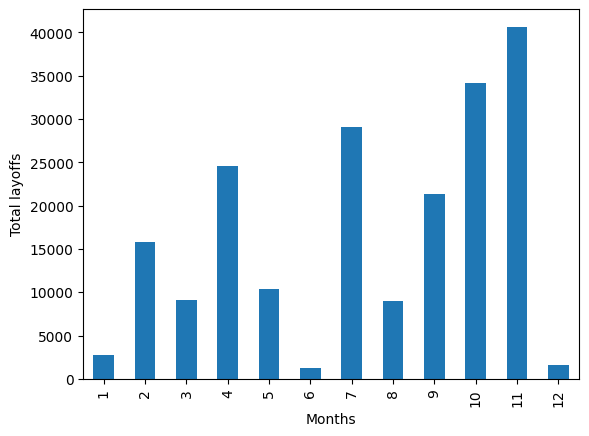

In [24]:
Year_2025 = df[df['Year_layoff'] == 2025].groupby("Month_layoff")["Laid_Off"].sum()
print(f'Monthly total number of layoffs happening in 2025: {Year_2025}')
Year_2025.plot(kind='bar')
plt.xlabel("Months")
plt.ylabel("Total layoffs") 
plt.savefig('Layoffs in 2025.png')


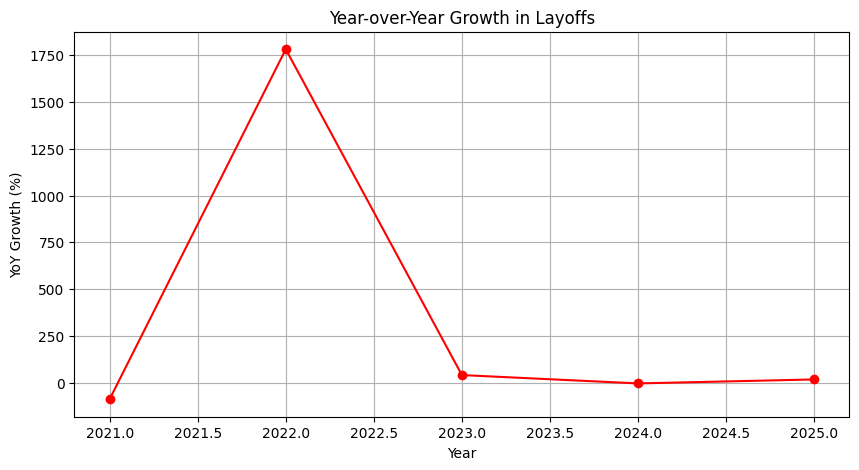

In [25]:
yearly_layoffs = (df.groupby("Year_layoff")["Laid_Off"].sum().sort_index())
yoy_growth = yearly_layoffs.pct_change() * 100
yoy_df = pd.DataFrame({ "Year": yearly_layoffs.index, "Layoffs": yearly_layoffs.values, "YoY_Growth_%": yoy_growth.values})

plt.figure(figsize=(10,5))

plt.plot(yoy_df["Year"], yoy_df["YoY_Growth_%"], marker="o", color="red")


plt.title("Year-over-Year Growth in Layoffs")
plt.xlabel("Year")
plt.ylabel("YoY Growth (%)")

plt.grid(True)
plt.savefig("YoY Growth in Layoffs.png")
plt.show()

Verifying the Datatypes

Insights 
   - In 2025, in the month of november, maximum layoffs had happened
   - In 2025, in the month of January, June and December least layoffs were seen


---------------------------------INDUSTRIES----------------------------------------------

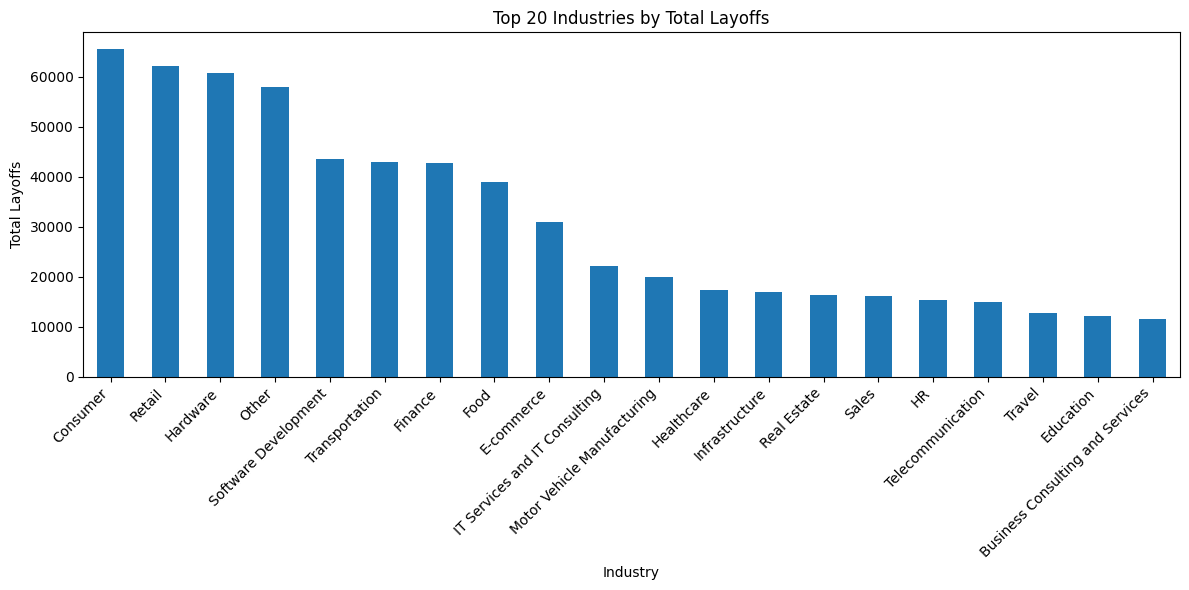

In [30]:
industry_layoffs = (df.groupby("Industry")["Laid_Off"].sum().sort_values(ascending=False).head(20))
plt.figure(figsize=(12,6))

industry_layoffs.plot(kind="bar")
plt.title("Top 20 Industries by Total Layoffs")
plt.ylabel("Total Layoffs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Top 20 Industries by Total Layoffs.png")
plt.show()


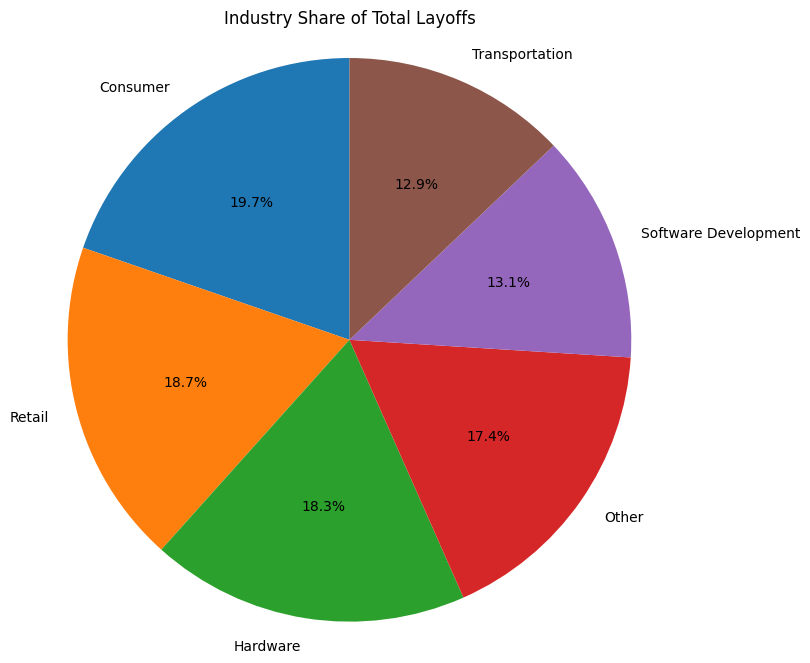

In [29]:
industry_share = df.groupby("Industry")['Laid_Off'].sum().sort_values(ascending=False).head(6)

plt.figure(figsize=(8, 8))
plt.pie(industry_share, labels=industry_share.index, autopct='%1.1f%%', startangle=90)
plt.title("Industry Share of Total Layoffs")
plt.axis('equal')
plt.savefig('Industry Share of Total Layoffs.png')
plt.show()


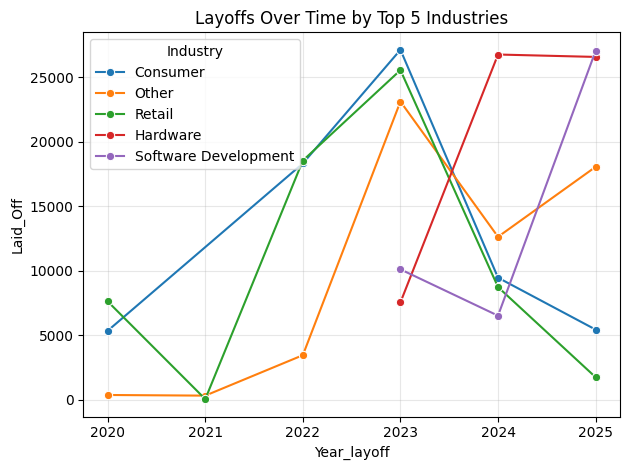

In [28]:
# Layoffs over time by industry

top5 = (df.groupby("Industry")["Laid_Off"].sum().nlargest(5).index)

# Filter data for only those industries
industry_over_time = (df[df["Industry"].isin(top5)].groupby(["Year_layoff", "Industry"])["Laid_Off"].sum().reset_index())

sns.lineplot(
    data=industry_over_time,
    x="Year_layoff",
    y="Laid_Off",
    hue="Industry",
    marker="o"
)
plt.title("Layoffs Over Time by Top 5 Industries")
plt.savefig("Layoffs Over Time by Top 5 Industries.png")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


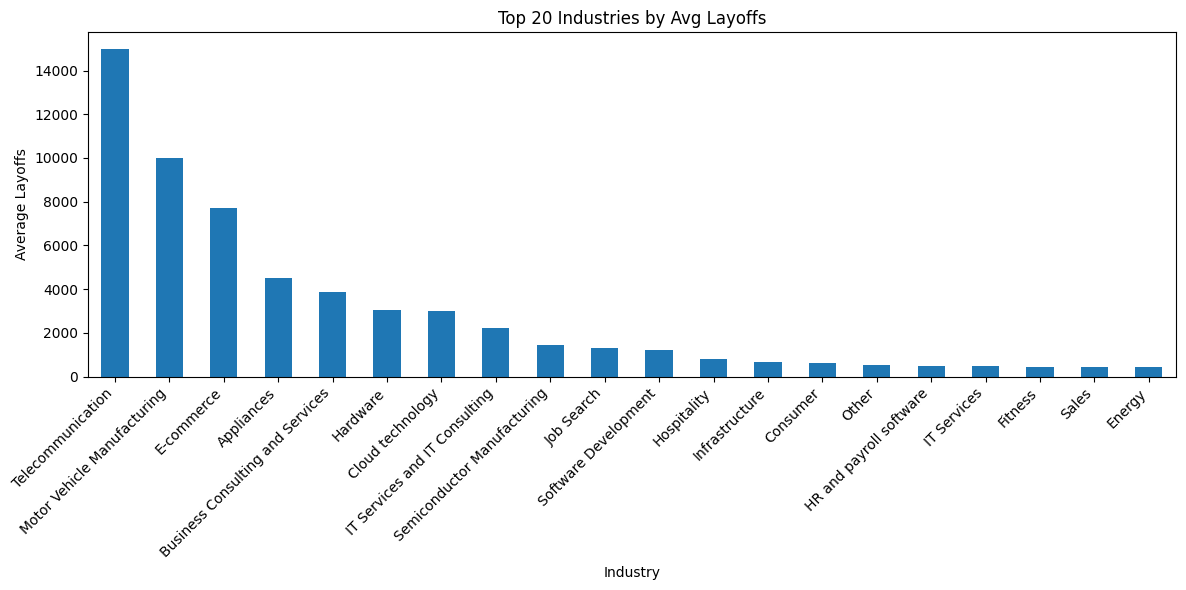

In [23]:
# Average layoffs per company in each industry
industry_avg_layoffs = (df.groupby("Industry")["Laid_Off"].mean().sort_values(ascending=False).head(20))
plt.figure(figsize=(12,6))

industry_avg_layoffs.plot(kind="bar")
plt.title("Top 20 Industries by Avg Layoffs")
plt.ylabel("Average Layoffs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Top 20 Industries by Avg Layoffs.png")
plt.show()


Insights: 
   - Consumer has the highest total layoffs, while Telecommunications has the highest average layoffs.
   - Healthcare, Infrastructure, Real Estate, Sales, HR, Telecommunication, Travel, Education and Business Consulting and Services maintained almost same number of total layoffs

---------------------------------COMPANIES---------------------------------------------

Company
Amazon                            72244.0
Intel                             42953.0
Microsoft                         31937.0
Meta                              25350.0
Tesla                             20520.0
Verizon                           15000.0
Google                            13982.0
Cisco                             13950.0
TCS                               12365.0
SAP                               11000.0
Accenture                         11000.0
SaleSan Francisco Bay Areaorce    10000.0
Toshiba                            9000.0
Ericsson                           8500.0
HP                                 8152.0
Flink                              8100.0
Uber                               7725.0
Micron                             7200.0
Oracle                             6404.0
Dell                               6000.0
Name: Laid_Off, dtype: float64


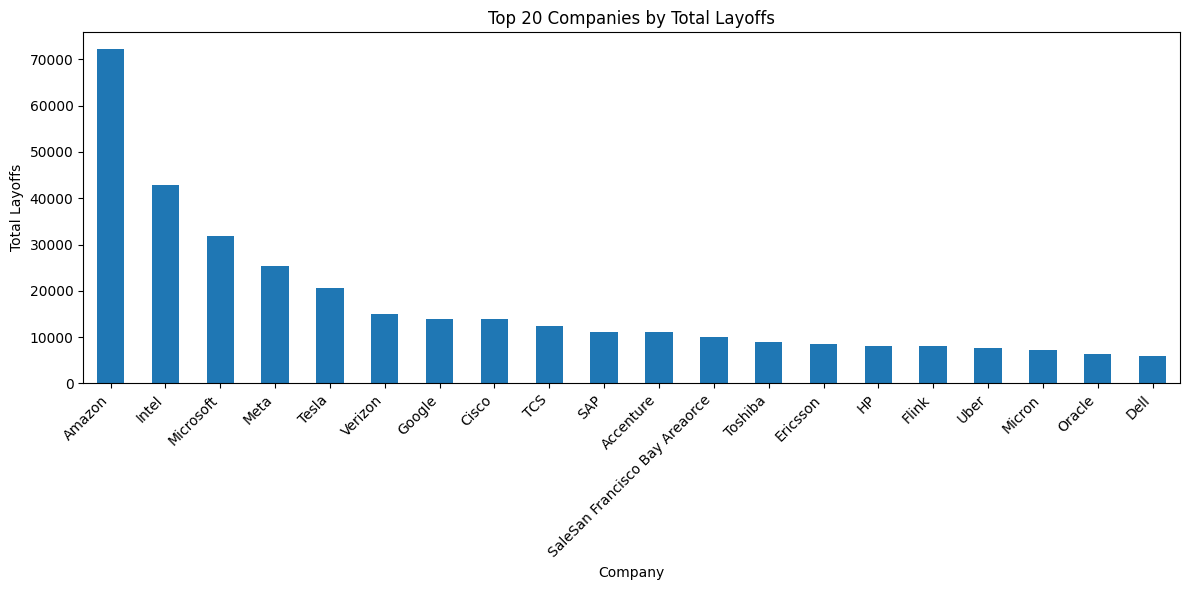

In [28]:
company = (df.groupby('Company')['Laid_Off'].sum().sort_values(ascending=False)).head(20)
print(company)
plt.figure(figsize=(12,6))
company.plot(kind="bar")
plt.title("Top 20 Companies by Total Layoffs")
plt.ylabel("Total Layoffs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Top 20 Companies by Total Layoffs.png")
plt.show()


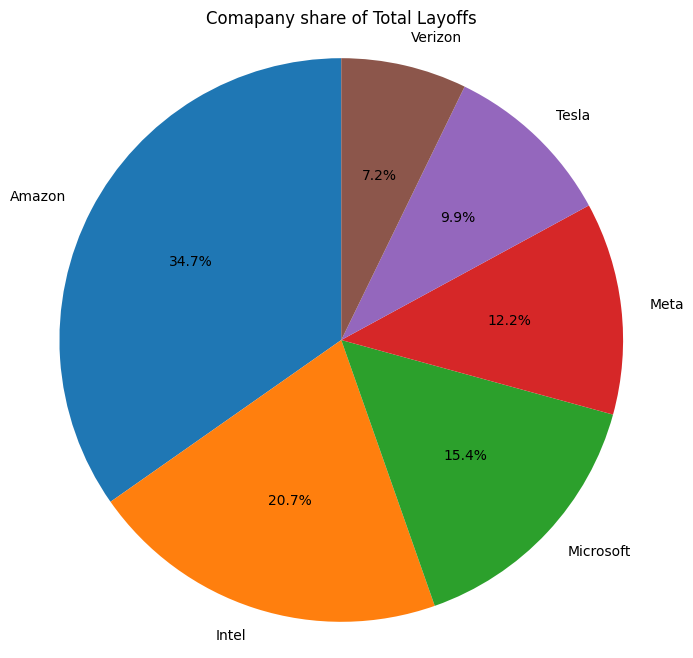

In [27]:
Comapany_share = df.groupby("Company")['Laid_Off'].sum().sort_values(ascending=False).head(6)

plt.figure(figsize=(8, 8))
plt.pie(Comapany_share, labels=Comapany_share.index, autopct='%1.1f%%', startangle=90)
plt.title("Comapany share of Total Layoffs")
plt.axis('equal')
plt.savefig('Comapany share of Total Layoffs.png')
plt.show()


Insights
  -  Company with the maximum layoffs is Amazon
  - Companies like Toshiba, Ericsson, HP, Flink, Uber, Micron, Oracle and Dell maintained almost same number of layoffs

---------------------------------COUNTRIES----------------------------------------------

Countries affected by layoffs: Country
USA                        541854.0
India                       55212.0
Germany                     28933.0
Sweden                      17201.0
UK                          17078.0
Canada                      14195.0
Israel                      13300.0
Ireland                     12191.0
Japan                        9298.0
Brazil                       7029.0
Singapore                    5316.0
Indonesia                    4291.0
Australia                    3164.0
Kenya                        2042.0
China                        1825.0
Nigeria                      1290.0
France                       1189.0
United Arabian Emirates      1088.0
Netherlands                  1030.0
New Zealand                  1025.0
Name: Laid_Off, dtype: float64


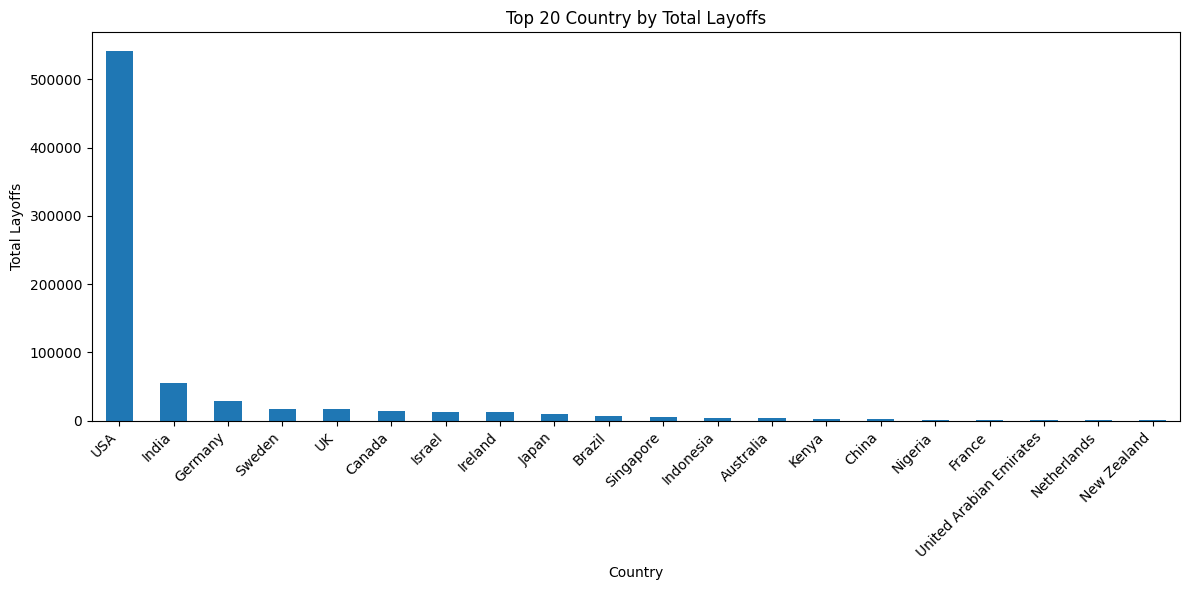

In [26]:
Country = (df.groupby('Country')['Laid_Off'].sum().sort_values(ascending=False)).head(20)
print(f'Countries affected by layoffs: {Country}')
plt.figure(figsize=(12,6))
Country.plot(kind="bar")
plt.title("Top 20 Country by Total Layoffs")
plt.ylabel("Total Layoffs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Top 20 Country by Total Layoffs.png")
plt.show()


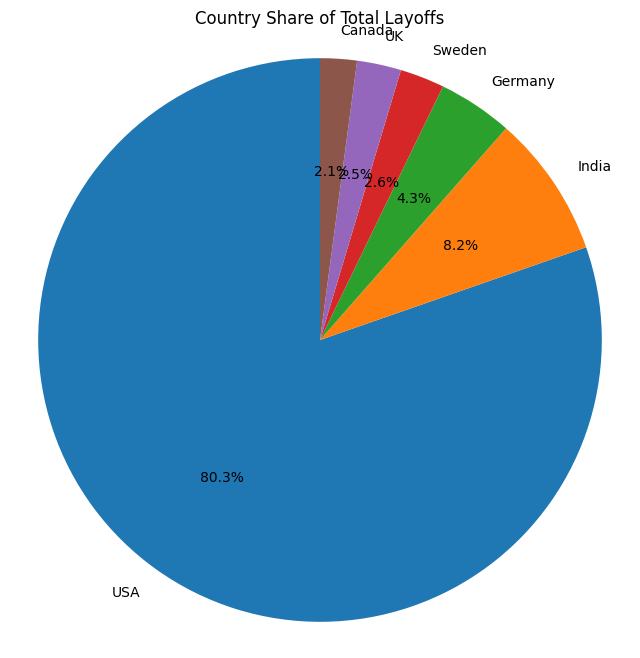

In [25]:
Country_share = df.groupby("Country")['Laid_Off'].sum().sort_values(ascending=False).head(6)

plt.figure(figsize=(8, 8))
plt.pie(Country_share, labels=Country_share.index, autopct='%1.1f%%', startangle=90)
plt.title("Country Share of Total Layoffs")
plt.axis('equal')
plt.savefig('Country Share of Total Layoffs.png')
plt.show()


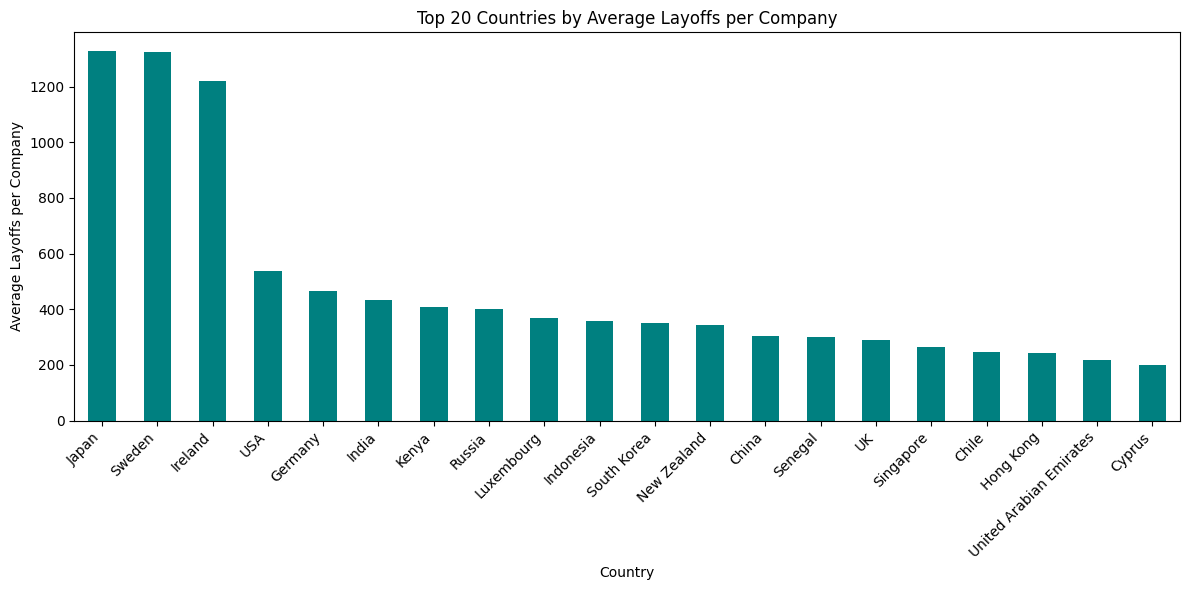

In [ ]:
#Total layoffs for each country
company_layoffs = df.groupby(["Country", "Company"])['Laid_Off'].sum().reset_index()

# Average layoffs per company in each country
avg_country = company_layoffs.groupby("Country")['Laid_Off'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(12,6))
avg_country.plot(kind="bar", color="teal")

plt.title("Top 20 Countries by Average Layoffs per Company")
plt.xlabel("Country")
plt.ylabel("Average Layoffs per Company")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("Top_20_Countries_Avg_Layoffs_Per_Company.png", dpi=300)
plt.show()

Insights
  - Country with the maximum layoffs is USA
  - Countries like Kenya, China, Nigeria, France, UAE, Netherlands and New Zealand maintained almost negligible number of layoffs

---------------------------------USA STATE----------------------------------------------

States in th USA affected by layoffs: USState
California              273605.0
Washington              116330.0
New York                 48862.0
Texas                    31944.0
Massachusetts            18056.0
Illinois                  8490.0
Idaho                     7200.0
Arizona                   5019.0
Oregon                    4258.0
Pennsylvania              4123.0
Florida                   4086.0
Connecticut               3720.0
Utah                      2546.0
Colorado                  2267.0
Georgia                   2184.0
Ohio                      1620.0
North Carolina            1466.0
Michigan                  1378.0
District of Columbia       947.0
Oklahoma                   500.0
Name: Laid_Off, dtype: float64


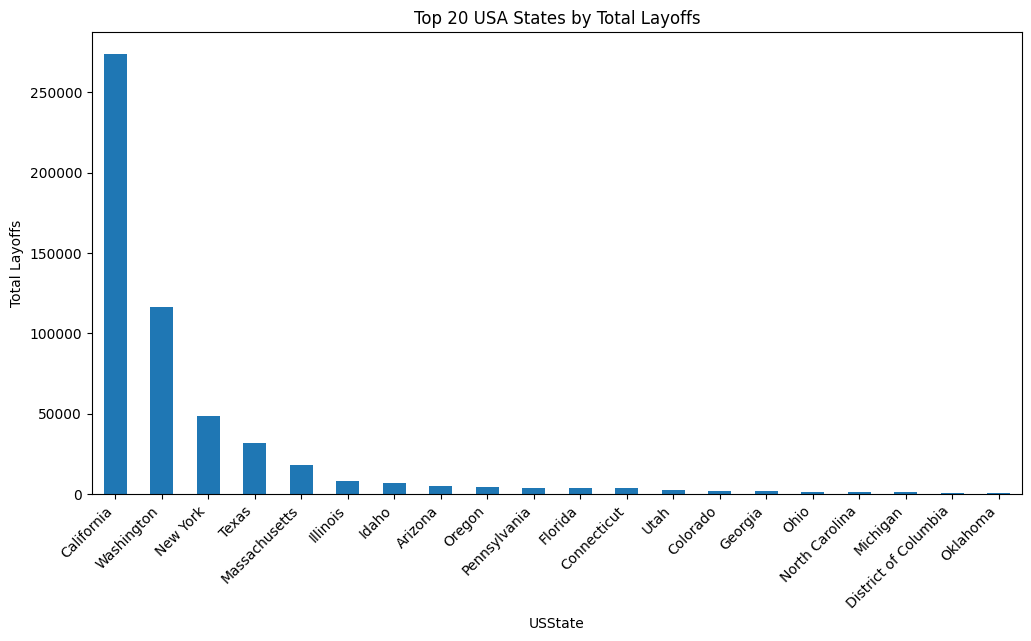

In [22]:
USA = df[df['Country'] == "USA"].groupby("USState")['Laid_Off'].sum().sort_values(ascending=False).head(20)
print(f'States in th USA affected by layoffs: {USA}')
plt.figure(figsize=(12,6))
USA.plot(kind="bar")
plt.title("Top 20 USA States by Total Layoffs")
plt.ylabel("Total Layoffs")
plt.xticks(rotation=45, ha="right")
plt.savefig("Top 20 USA States by Total Layoffs.png")
plt.show()


percentage contributions of USA States in layoffs: USState
California              50.799200
Washington              21.598549
New York                 9.072022
Texas                    5.930921
Massachusetts            3.352389
Illinois                 1.576306
Idaho                    1.336797
Arizona                  0.931859
Oregon                   0.790567
Pennsylvania             0.765502
Florida                  0.758632
Connecticut              0.690678
Utah                     0.472706
Colorado                 0.420905
Georgia                  0.405495
Ohio                     0.300779
North Carolina           0.272187
Michigan                 0.255848
District of Columbia     0.175826
Oklahoma                 0.092833
Name: Laid_Off, dtype: float64


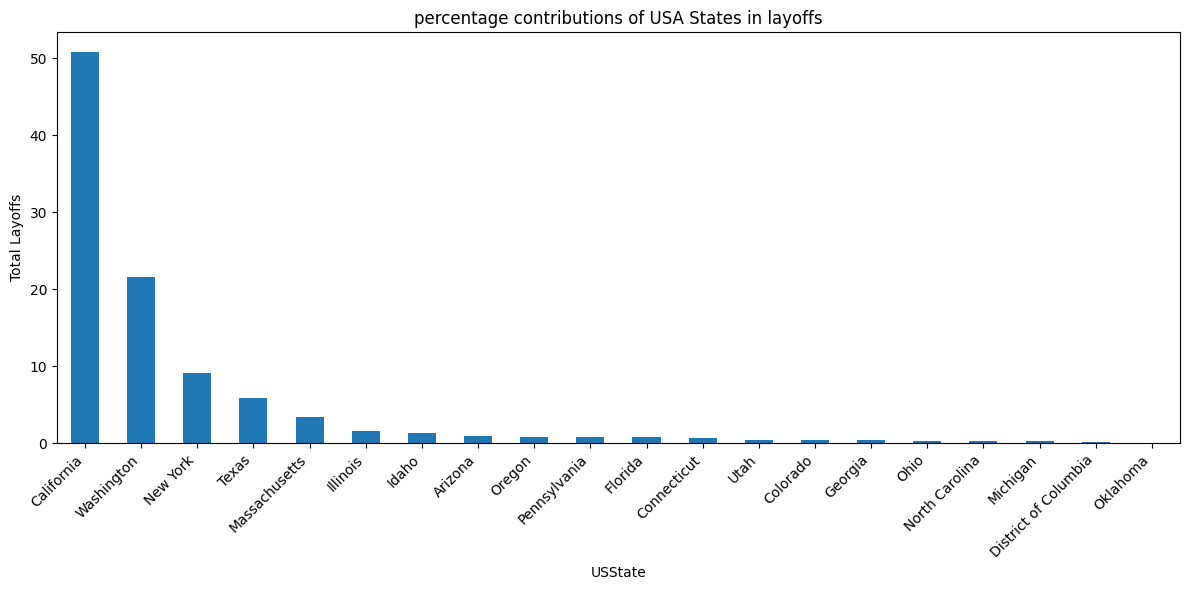

In [24]:
USA_state = df[df['Country'] == "USA"].groupby("USState")['Laid_Off'].sum().sort_values(ascending=False).head(20)
USA_state_percentage = (USA_state/USA_state.sum())*100

print(f'percentage contributions of USA States in layoffs: {USA_state_percentage}')
plt.figure(figsize=(12,6))
USA_state_percentage.plot(kind="bar")

plt.title("percentage contributions of USA States in layoffs")
plt.ylabel("Total Layoffs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("percentage contributions of USA States in layoffs.png")

plt.show()


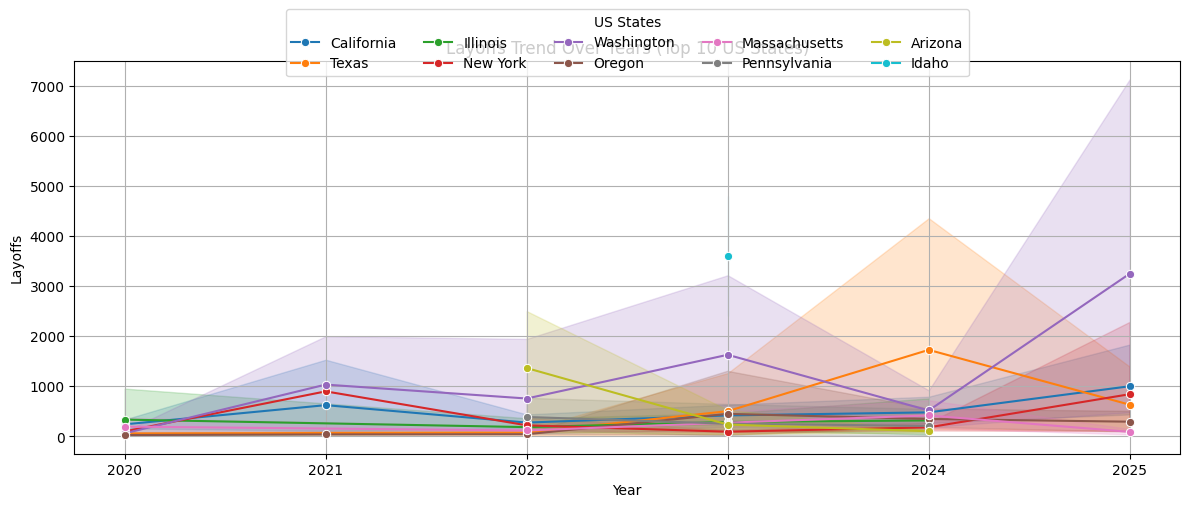

In [37]:
us_df = df[df["Country"] == "USA"]

# Get top 10 states by total layoffs
top_states = (
    us_df.groupby("USState")["Laid_Off"]
    .sum()
    .nlargest(10)
    .index
)

# Filter only those states
state_trend = us_df[us_df["USState"].isin(top_states)]

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=state_trend,
    x="Year_layoff",
    y="Laid_Off",
    hue="USState",
    marker="o"
)

plt.title("Layoffs Trend Over Years (Top 10 US States)")
plt.xlabel("Year")
plt.ylabel("Layoffs")
plt.grid(True)

plt.legend(
    title="US States",
    bbox_to_anchor=(0.5, 1.15),
    loc="upper center",
    ncol=5
)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig("Layoffs Trend Over Years (Top 10 US States).png")
plt.show()

Insights
  - USA State with the maximum layoffs is California
  - States like Utah, Colorado, Georgia, Ohio, North Carolina, Michigan, District of Columbia and Oklahoma maintained almost negligible number of layoffs

Statistical Analysis

Skewness: 10.788443160839588


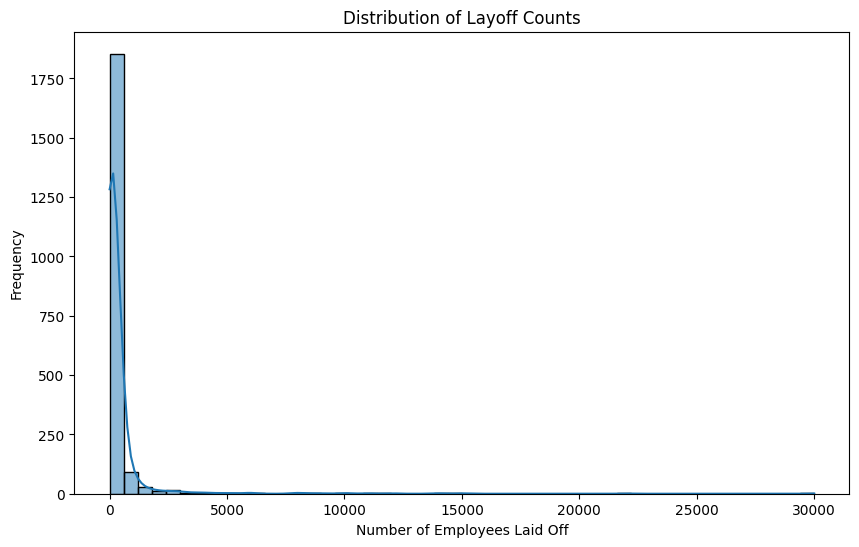

In [42]:
print("Skewness:", df['Laid_Off'].skew())
plt.figure(figsize=(10,6))
sns.histplot(df['Laid_Off'], bins = 50, kde=True)
plt.title('Distribution of Layoff Counts')
plt.xlabel('Number of Employees Laid Off')
plt.ylabel('Frequency')
plt.savefig("Distribution of Layoff Counts.png")
plt.show()

In [50]:
layoffs_per_company = df.groupby('Company')['Laid_Off'].sum()
layoffs_per_company_mean = layoffs_per_company.mean()
layoffs_per_company_median = layoffs_per_company.median()
layoffs_per_company_std = layoffs_per_company.std()

print("Mean:", layoffs_per_company_mean)
print("Median:", layoffs_per_company_median)
print("Standard Deviation:", layoffs_per_company_std)

Mean: 458.01657458563534
Median: 80.0
Standard Deviation: 2599.669327223075
